<a href="https://colab.research.google.com/github/MoinulHossain142/Customer-Churn-Prediction/blob/main/Day_02_Market_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

print("Ready ✓")

Ready ✓


In [2]:
# Our first 5 tickers — a mix of sectors
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

# Fetch 5 years of daily data
raw_data = {}

for ticker in TICKERS:
    print(f"Fetching {ticker}...", end=" ")
    df = yf.download(
        ticker,
        start="2019-01-01",
        end="2024-12-31",
        auto_adjust=True,    # ← gives you adjusted close automatically
        progress=False
    )
    raw_data[ticker] = df
    print(f"{len(df)} rows ✓")

print("\nAll tickers fetched ✓")

Fetching AAPL... 1509 rows ✓
Fetching MSFT... 1509 rows ✓
Fetching GOOGL... 1509 rows ✓
Fetching AMZN... 1509 rows ✓
Fetching TSLA... 1509 rows ✓

All tickers fetched ✓


In [3]:
# Look at the first ticker
sample = raw_data["AAPL"]

print("Shape:", sample.shape)
print("\nColumns:", sample.columns.tolist())
print("\nDate range:", sample.index[0].date(), "→", sample.index[-1].date())
print("\nFirst 5 rows:")
sample.head()

Shape: (1509, 5)

Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

Date range: 2019-01-02 → 2024-12-30

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503719,37.724583,36.627397,36.784138,148158800
2019-01-03,33.768085,34.606410,33.722963,34.193183,365248800
2019-01-04,35.209610,35.278483,34.150426,34.323790,234428400
2019-01-07,35.131252,35.344992,34.649157,35.314117,219111200
2019-01-08,35.800953,36.055064,35.271361,35.518344,164101200


In [4]:
# Fetch RAW (unadjusted) vs ADJUSTED Apple data side by side
# to see why adjustment matters

raw   = yf.download("AAPL", start="2019-01-01", end="2024-12-31",
                    auto_adjust=False, progress=False)
adj   = yf.download("AAPL", start="2019-01-01", end="2024-12-31",
                    auto_adjust=True,  progress=False)

print("=== RAW close (first 5 rows) ===")
print(raw[["Close","Volume"]].head())

print("\n=== ADJUSTED close (first 5 rows) ===")
print(adj[["Close","Volume"]].head())

print("""
WHY THIS MATTERS:
- Raw close = the literal price on that day
- Adjusted close = corrects for stock splits and dividends
- Apple did a 4-for-1 split in Aug 2020 — raw prices before that
  look 4x higher than they really were in today's terms
- ALWAYS use auto_adjust=True for any model training
  Otherwise your model learns fake price jumps as signals
""")

=== RAW close (first 5 rows) ===
Price           Close     Volume
Ticker           AAPL       AAPL
Date                            
2019-01-02  39.480000  148158800
2019-01-03  35.547501  365248800
2019-01-04  37.064999  234428400
2019-01-07  36.982498  219111200
2019-01-08  37.687500  164101200

=== ADJUSTED close (first 5 rows) ===
Price           Close     Volume
Ticker           AAPL       AAPL
Date                            
2019-01-02  37.503719  148158800
2019-01-03  33.768085  365248800
2019-01-04  35.209610  234428400
2019-01-07  35.131252  219111200
2019-01-08  35.800953  164101200

WHY THIS MATTERS:
- Raw close = the literal price on that day
- Adjusted close = corrects for stock splits and dividends
- Apple did a 4-for-1 split in Aug 2020 — raw prices before that
  look 4x higher than they really were in today's terms
- ALWAYS use auto_adjust=True for any model training
  Otherwise your model learns fake price jumps as signals



In [8]:
def check_data_quality(ticker, df):
    issues = []

    # Missing dates (trading days only — ~252/year)
    missing_vals = df.isnull().sum()
    if missing_vals.any():
        issues.append(f"  ⚠ Missing values: {missing_vals[missing_vals>0].to_dict()}")

    # Duplicate index dates
    dupes = df.index.duplicated().sum()
    if dupes:
        issues.append(f"  ⚠ Duplicate dates: {dupes}")

    # Zero volume days (suspicious)
    # Corrected column access for MultiIndex
    zero_vol = (df[('Volume', ticker)] == 0).sum()
    if zero_vol:
        issues.append(f"  ⚠ Zero volume days: {zero_vol}")

    # Negative prices (should never happen)
    # Corrected column access for multiple columns in MultiIndex
    price_cols = [('Open', ticker), ('High', ticker), ('Low', ticker), ('Close', ticker)]
    neg_prices = (df[price_cols] < 0).any().any()
    if neg_prices:
        issues.append(f"  ⚠ Negative prices found!")

    # High > Low check
    # Corrected column access for MultiIndex
    bad_hl = (df[('High', ticker)] < df[('Low', ticker)]).sum()
    if bad_hl:
        issues.append(f"  ⚠ High < Low on {bad_hl} rows")

    if issues:
        print(f"\n{ticker} — issues found:")
        for i in issues: print(i)
    else:
        print(f"{ticker} — clean ✓  ({len(df)} rows, {df.index[0].date()} → {df.index[-1].date()})")

    return len(issues) == 0

print("=== DATA QUALITY REPORT ===\n")
results = {}
for ticker, df in raw_data.items():
    results[ticker] = check_data_quality(ticker, df)

all_clean = all(results.values())
print(f"\nOverall: {'All clean ✓' if all_clean else 'Issues found — see above'}")

=== DATA QUALITY REPORT ===

AAPL — clean ✓  (1509 rows, 2019-01-02 → 2024-12-30)
MSFT — clean ✓  (1509 rows, 2019-01-02 → 2024-12-30)
GOOGL — clean ✓  (1509 rows, 2019-01-02 → 2024-12-30)
AMZN — clean ✓  (1509 rows, 2019-01-02 → 2024-12-30)
TSLA — clean ✓  (1509 rows, 2019-01-02 → 2024-12-30)

Overall: All clean ✓


In [10]:
def clean_ohlcv(df):
    df = df.copy()

    # Forward-fill missing values (e.g. public holidays in some feeds)
    df = df.ffill()

    # Drop any remaining NaN rows (start-of-series gaps)
    df = df.dropna()

    # Ensure index is proper DatetimeIndex
    df.index = pd.to_datetime(df.index)
    df.index.name = "Date"

    # Rename columns to lowercase for consistency
    # Corrected: Access the string part of the MultiIndex tuple before calling .lower()
    df.columns = [c[0].lower() for c in df.columns]

    return df

cleaned_data = {}
for ticker, df in raw_data.items():
    cleaned_data[ticker] = clean_ohlcv(df)
    print(f"{ticker} cleaned: {len(cleaned_data[ticker])} rows")

AAPL cleaned: 1509 rows
MSFT cleaned: 1509 rows
GOOGL cleaned: 1509 rows
AMZN cleaned: 1509 rows
TSLA cleaned: 1509 rows


In [11]:
# Save each ticker to its own CSV file
data_dir = "/content/stock-predictor/data"
os.makedirs(data_dir, exist_ok=True)

for ticker, df in cleaned_data.items():
    path = f"{data_dir}/{ticker}_daily.csv"
    df.to_csv(path)
    print(f"Saved {path}  ({os.path.getsize(path)/1024:.1f} KB)")

print("\nAll files saved ✓")

Saved /content/stock-predictor/data/AAPL_daily.csv  (139.1 KB)
Saved /content/stock-predictor/data/MSFT_daily.csv  (138.3 KB)
Saved /content/stock-predictor/data/GOOGL_daily.csv  (137.9 KB)
Saved /content/stock-predictor/data/AMZN_daily.csv  (133.3 KB)
Saved /content/stock-predictor/data/TSLA_daily.csv  (134.9 KB)

All files saved ✓


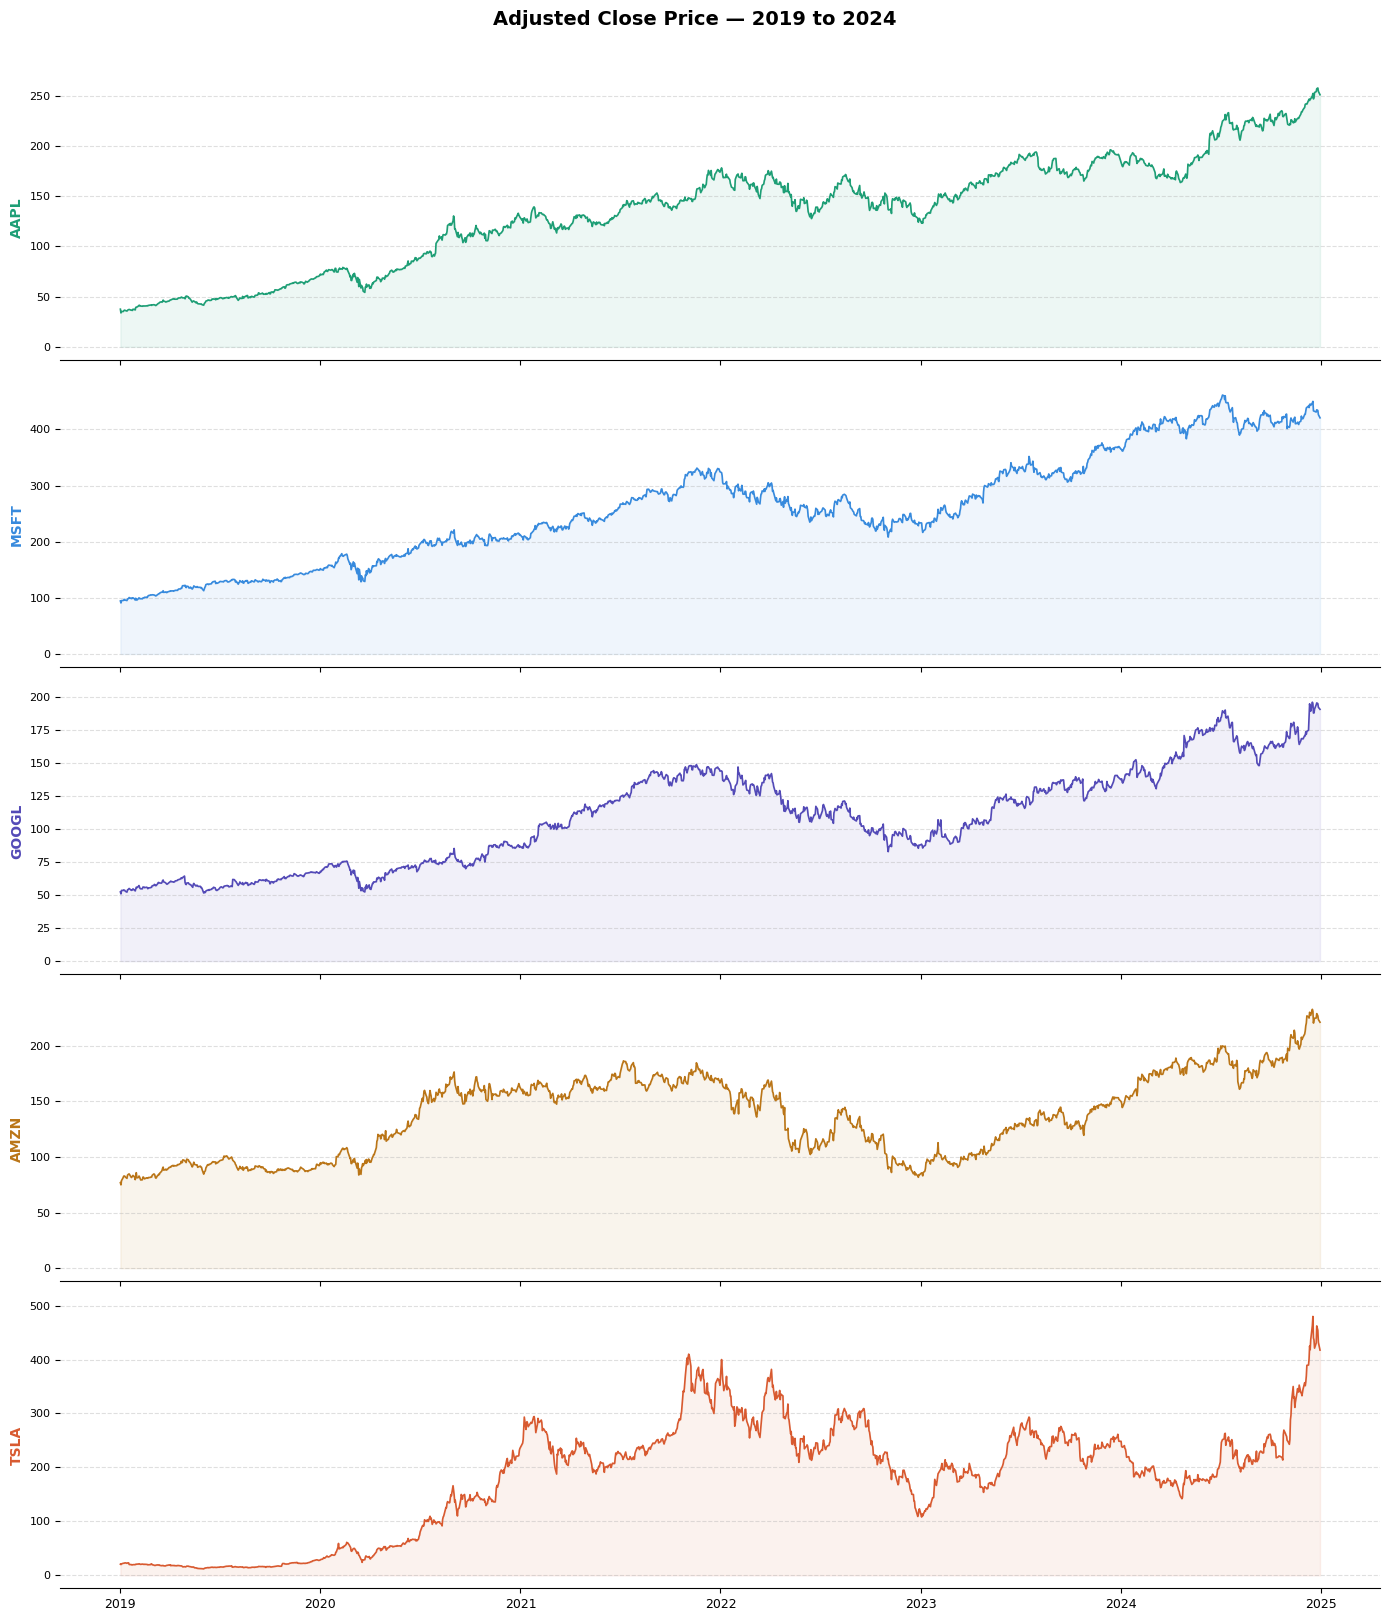

Chart saved ✓


In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 16), sharex=True)
fig.suptitle("Adjusted Close Price — 2019 to 2024", fontsize=14, fontweight="bold", y=1.01)

colors = ["#1D9E75","#378ADD","#534AB7","#BA7517","#D85A30"]

for ax, (ticker, df), color in zip(axes, cleaned_data.items(), colors):
    ax.plot(df.index, df["close"], color=color, linewidth=1.2)
    ax.fill_between(df.index, df["close"], alpha=0.08, color=color)
    ax.set_ylabel(ticker, fontsize=10, fontweight="bold", color=color)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top","right","left"]].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(f"{data_dir}/price_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved ✓")

In [13]:
print("=== SUMMARY STATISTICS (Close Price) ===\n")
summary_rows = []

for ticker, df in cleaned_data.items():
    close = df["close"]
    summary_rows.append({
        "Ticker"     : ticker,
        "Start Date" : df.index[0].date(),
        "End Date"   : df.index[-1].date(),
        "Trading Days": len(df),
        "Min Price"  : f"${close.min():.2f}",
        "Max Price"  : f"${close.max():.2f}",
        "Latest"     : f"${close.iloc[-1]:.2f}",
        "Total Return": f"{((close.iloc[-1]/close.iloc[0])-1)*100:.1f}%"
    })

summary_df = pd.DataFrame(summary_rows).set_index("Ticker")
print(summary_df.to_string())

=== SUMMARY STATISTICS (Close Price) ===

        Start Date    End Date  Trading Days Min Price Max Price   Latest Total Return
Ticker                                                                                
AAPL    2019-01-02  2024-12-30          1509    $33.77   $257.61  $250.83       568.8%
MSFT    2019-01-02  2024-12-30          1509    $90.92   $461.32  $420.76       345.7%
GOOGL   2019-01-02  2024-12-30          1509    $50.85   $195.75  $190.36       264.0%
AMZN    2019-01-02  2024-12-30          1509    $75.01   $232.93  $221.30       187.6%
TSLA    2019-01-02  2024-12-30          1509    $11.93   $479.86  $417.41      1918.9%


In [14]:
fetch_code = '''
import yfinance as yf
import pandas as pd
import os

def fetch_ohlcv(ticker: str,
                start: str = "2019-01-01",
                end: str   = "2024-12-31",
                save_dir: str = None) -> pd.DataFrame:
    """
    Fetch adjusted OHLCV data for a single ticker.
    Cleans, validates, and optionally saves to CSV.

    Args:
        ticker   : stock symbol e.g. "AAPL"
        start    : start date string "YYYY-MM-DD"
        end      : end date string  "YYYY-MM-DD"
        save_dir : if provided, saves CSV to this folder

    Returns:
        cleaned DataFrame with columns: open high low close volume
    """
    df = yf.download(ticker, start=start, end=end,
                     auto_adjust=True, progress=False)

    if df.empty:
        raise ValueError(f"No data returned for {ticker}. Check the symbol.")

    # Clean
    df = df.ffill().dropna()
    df.columns = [c.lower() for c in df.columns]
    df.index = pd.to_datetime(df.index)
    df.index.name = "Date"

    # Validate minimum rows
    if len(df) < 100:
        raise ValueError(f"{ticker} has only {len(df)} rows — not enough data.")

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{ticker}_daily.csv")
        df.to_csv(path)

    return df
'''

# Write it to the src folder
src_dir = "/content/stock-predictor/src"
os.makedirs(src_dir, exist_ok=True)

with open(f"{src_dir}/data_fetch.py", "w") as f:
    f.write(fetch_code)

print("Saved: src/data_fetch.py ✓")

Saved: src/data_fetch.py ✓


In [16]:
import sys
sys.path.append("/content/stock-predictor/src")

import yfinance as yf
import pandas as pd
import os

# Redefining the function locally to incorporate the fix
def fetch_ohlcv(ticker: str,
                start: str = "2019-01-01",
                end: str   = "2024-12-31",
                save_dir: str = None) -> pd.DataFrame:
    """
    Fetch adjusted OHLCV data for a single ticker.
    Cleans, validates, and optionally saves to CSV.

    Args:
        ticker   : stock symbol e.g. "AAPL"
        start    : start date string "YYYY-MM-DD"
        end      : end date string  "YYYY-MM-DD"
        save_dir : if provided, saves CSV to this folder

    Returns:
        cleaned DataFrame with columns: open high low close volume
    """
    df = yf.download(ticker, start=start, end=end,
                     auto_adjust=True, progress=False)

    if df.empty:
        raise ValueError(f"No data returned for {ticker}. Check the symbol.")

    # Clean
    df = df.ffill().dropna()
    # FIX: Access the string part of the MultiIndex tuple before calling .lower()
    df.columns = [c[0].lower() for c in df.columns]
    df.index = pd.to_datetime(df.index)
    df.index.name = "Date"

    # Validate minimum rows
    if len(df) < 100:
        raise ValueError(f"{ticker} has only {len(df)} rows — not enough data.")

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{ticker}_daily.csv")
        df.to_csv(path)

    return df

# Test it
df_test = fetch_ohlcv("NVDA", start="2019-01-01", end="2024-12-31",
                       save_dir="/content/stock-predictor/data")

print(f"NVDA fetched: {len(df_test)} rows")
print(df_test.tail(3))
print("\nfetch_ohlcv() function works ✓")

NVDA fetched: 1509 rows
                 close        high         low        open     volume
Date                                                                 
2024-12-26  139.884171  140.803883  137.684894  139.654250  116205600
2024-12-27  136.965103  138.974454  134.665869  138.504607  170582600
2024-12-30  137.444946  140.224034  133.976082  134.785814  167734700

fetch_ohlcv() function works ✓


In [17]:
from google.colab import userdata
import subprocess, os

GITHUB_TOKEN    = userdata.get("GITHUB_TOKEN")
GITHUB_USERNAME = userdata.get("GITHUB_USERNAME")
REPO_NAME       = "stock-predictor"

os.chdir(f"/content/{REPO_NAME}")
os.system('git config --global user.email "your@email.com"')
os.system('git config --global user.name "Your Name"')

subprocess.run(["git", "add", "-A"])
result = subprocess.run(["git", "commit", "-m",
    "Day 2: data fetch pipeline, 5 tickers, quality checks, fetch_ohlcv() module"],
    capture_output=True, text=True)
print(result.stdout or "Nothing new to commit")

push = subprocess.run(["git", "push"], capture_output=True, text=True)
print(push.stdout or push.stderr)
print("Pushed ✓")

SecretNotFoundError: Secret GITHUB_TOKEN does not exist.